# Phase 1 EDA — Lending Club loans (2007–2015, 36-month)

**Question this project answers:** given only what an investor sees when a loan is
listed, should they fund it?

This notebook checks the assumptions written in `PLAN.md` against the real data.
Every finding that changes the pipeline is recorded in `DECISIONS.md` — the notebook
itself contains no pipeline logic (D-013).

In [1]:
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from lending_club.config import load_params, path_of

sns.set_theme(style="whitegrid")
PARAMS = load_params()
FIG = path_of("figures_dir")
FIG.mkdir(parents=True, exist_ok=True)

raw = pl.read_parquet(path_of("raw_parquet"))  # all loans, allowlisted columns
df = pl.read_parquet(path_of("prepared"))  # cleaned, labeled, filtered
print(f"raw:      {raw.height:,} loans")
print(f"prepared: {df.height:,} loans   default rate: {df['target'].mean():.4f}")

raw:      2,260,668 loans
prepared: 621,022 loans   default rate: 0.1395


## 1. The filter funnel

We start with 2.26M loans and keep 621k. Each filter has a reason:
a loan with no final outcome cannot be labeled, and a loan issued too recently
cannot have finished.

In [2]:
status = raw.group_by("loan_status").len().sort("len", descending=True).to_pandas()
display(status)

steps = {
    "all loans": raw.height,
    "36-month term": raw.filter(pl.col("term").str.contains("36")).height,
    "+ known outcome": raw.filter(
        pl.col("term").str.contains("36"),
        pl.col("loan_status")
        .str.replace("Does not meet the credit policy. Status:", "", literal=True)
        .is_in(["Fully Paid", "Charged Off", "Default"]),
    ).height,
    "+ matured (issued <= 2015-12)": df.height,
}
for k, v in steps.items():
    print(f"{k:32s} {v:>10,}")

,loan_status,len
0,Fully Paid,1076751
1,Current,878317
2,Charged Off,268559
3,Late (31-120 days),21467
4,In Grace Period,8436
5,Late (16-30 days),4349
6,Does not meet the credit policy. Status:Fully ...,1988
7,Does not meet the credit policy. Status:Charge...,761
8,Default,40


all loans                         2,260,668
36-month term                     1,609,754
+ known outcome                   1,023,206
+ matured (issued <= 2015-12)       621,022


## 2. Why we drop loans issued after 2015 (the maturity trap)

The dataset is a snapshot from the end of 2018. A 36-month loan issued in 2017 can
only appear "finished" if it ended early — and early endings are mostly defaults.
So the observed default rate for recent years is inflated by the snapshot, not by
riskier borrowers.

The chart below is the evidence for decision **D-004**: the rate jumps after 2015,
which is exactly where loans stop having enough time to mature.

,year,n,default_rate
0,2007,603,0.262023
1,2008,2393,0.207271
2,2009,5281,0.136906
3,2010,9156,0.109218
4,2011,14101,0.106305
5,2012,43470,0.135795
6,2013,100422,0.123260
7,2014,162570,0.137264
8,2015,283026,0.148863
9,2016,232361,0.198484


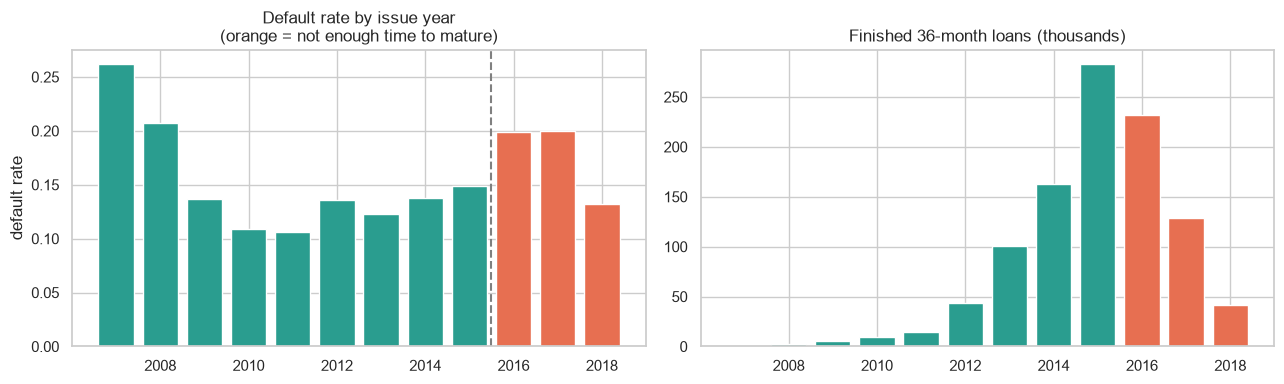

In [3]:
matured_cut = 2015
by_year = (
    raw.with_columns(
        pl.col("issue_d").str.to_date("%b-%Y").dt.year().alias("year"),
        pl.col("loan_status")
        .str.replace("Does not meet the credit policy. Status:", "", literal=True)
        .alias("s"),
    )
    .filter(
        pl.col("term").str.contains("36"),
        pl.col("s").is_in(["Fully Paid", "Charged Off", "Default"]),
    )
    .group_by("year")
    .agg(
        pl.len().alias("n"),
        pl.col("s").is_in(["Charged Off", "Default"]).mean().alias("default_rate"),
    )
    .sort("year")
    .to_pandas()
)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
colors = ["#2a9d8f" if y <= matured_cut else "#e76f51" for y in by_year.year]
ax[0].bar(by_year.year, by_year.default_rate, color=colors)
ax[0].axvline(matured_cut + 0.5, ls="--", c="grey")
ax[0].set_title("Default rate by issue year\n(orange = not enough time to mature)")
ax[0].set_ylabel("default rate")
ax[1].bar(by_year.year, by_year.n / 1000, color=colors)
ax[1].set_title("Finished 36-month loans (thousands)")
plt.tight_layout()
plt.savefig(FIG / "maturity_bias.png", dpi=120)
display(by_year)

## 3. The time split, and the drift inside it

Train on 2007–2013, tune on 2014, test once on 2015 (**D-005**). Note the default
rate *rises* across the three splits: the model will be trained on an easier period
than the one it is tested on. That is realistic — a model in production always
faces a slightly different world — and it is why calibration matters (**D-024**).

In [4]:
split_cfg = PARAMS["split"]
rows = []
for name, cfg in split_cfg.items():
    if name == "cv_folds":
        continue
    s = df.filter(
        pl.col("issue_date").is_between(
            pl.lit(cfg["start"]).str.to_date(), pl.lit(cfg["end"]).str.to_date()
        )
    )
    rows.append(
        {
            "split": name,
            "loans": s.height,
            "default_rate": round(s["target"].mean(), 4),
            "avg_loan": round(s["loan_amnt"].mean()),
            "avg_int_rate": round(s["int_rate"].mean(), 2),
        }
    )
display(pl.DataFrame(rows).to_pandas())

,split,loans,default_rate,avg_loan,avg_int_rate
0,train,175426,0.1263,11860,12.80
1,validation,162570,0.1373,12586,12.47
2,test,283026,0.1489,12806,11.28


## 4. Does Lending Club's own grade already solve the problem?

`grade` and `int_rate` are assigned by Lending Club before the listing goes live, so
an investor can see them — which means our model has to beat them, not just
rediscover them (**D-007**). Default risk rises steeply from A to G, so the grade is
clearly informative. The question for Phase 3 is whether the other columns add
anything on top of it.

,grade,loans,default_rate,avg_int_rate,avg_profit
0,A,143006,0.054774,7.215803,1009.248500
1,B,211967,0.112117,10.864124,1113.137356
2,C,162402,0.179339,13.921279,1025.048266
3,D,76663,0.233607,17.161011,949.519823
4,E,21836,0.285446,19.764321,764.776687
5,F,4465,0.330123,23.324511,531.167090
6,G,683,0.387994,23.939780,445.740919


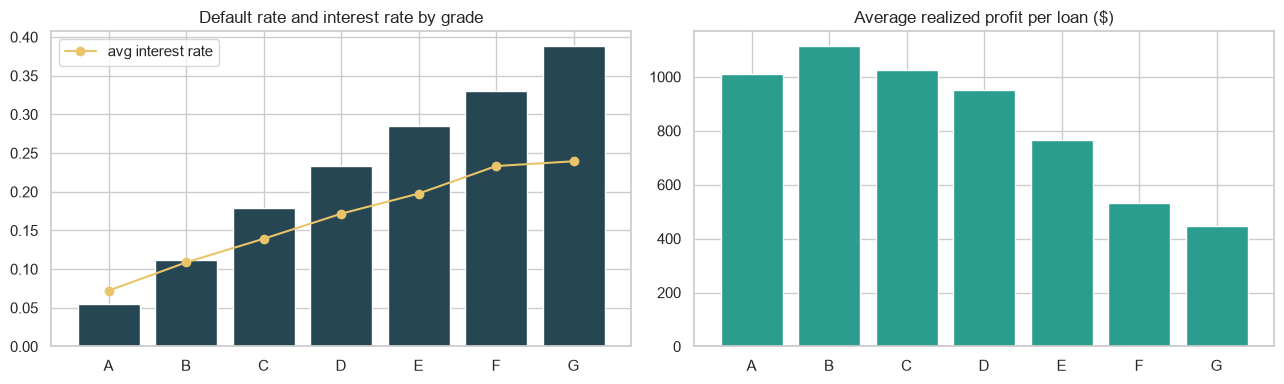

In [5]:
by_grade = (
    df.group_by("grade")
    .agg(
        pl.len().alias("loans"),
        pl.col("target").mean().alias("default_rate"),
        pl.col("int_rate").mean().alias("avg_int_rate"),
        pl.col("realized_profit").mean().alias("avg_profit"),
    )
    .sort("grade")
    .to_pandas()
)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(by_grade.grade, by_grade.default_rate, color="#264653")
ax[0].plot(
    by_grade.grade, by_grade.avg_int_rate / 100, "o-", color="#e9c46a", label="avg interest rate"
)
ax[0].set_title("Default rate and interest rate by grade")
ax[0].legend()
ax[1].bar(
    by_grade.grade,
    by_grade.avg_profit,
    color=["#2a9d8f" if v > 0 else "#e76f51" for v in by_grade.avg_profit],
)
ax[1].axhline(0, c="black", lw=1)
ax[1].set_title("Average realized profit per loan ($)")
plt.tight_layout()
plt.savefig(FIG / "risk_by_grade.png", dpi=120)
display(by_grade)

## 5. What the investor actually earns

`realized_profit = total_pymnt - funded_amnt`. These columns are known only *after*
the loan ends, so they are used **only for evaluation**, never as features (**D-008**).

Two numbers drive the whole profit policy:
* a repaid loan returns about **+15%** over three years,
* a charged-off loan still repays about **64%** of the principal, so the loss given
  default is roughly **36%**, not the 65% we assumed in the plan (**D-032**).

Because the average loan is profitable, "fund everything" is a genuinely strong
baseline — the model has to beat a positive number, not zero.

,target,loans,avg_profit,payback_ratio
0,repaid,534418,1911.818381,1.154977
1,defaulted,86604,-4420.055490,0.634551


Implied loss given default (LGD): 0.365
Fund-everything baseline: $1028.81 per loan, 0.0825 per dollar invested


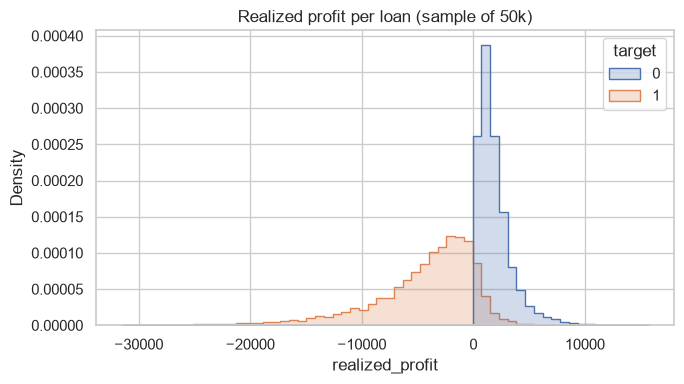

In [6]:
profit = (
    df.group_by("target")
    .agg(
        pl.len().alias("loans"),
        pl.col("realized_profit").mean().alias("avg_profit"),
        (pl.col("total_pymnt") / pl.col("funded_amnt")).mean().alias("payback_ratio"),
    )
    .sort("target")
    .to_pandas()
)
profit["target"] = profit["target"].map({0: "repaid", 1: "defaulted"})
display(profit)

lgd = 1 - (
    df.filter(pl.col("target") == 1)
    .select((pl.col("total_pymnt") / pl.col("funded_amnt")).mean())
    .item()
)
print(f"Implied loss given default (LGD): {lgd:.3f}")
print(
    f"Fund-everything baseline: ${df['realized_profit'].mean():.2f} per loan, "
    f"{df['realized_profit'].sum() / df['funded_amnt'].sum():.4f} per dollar invested"
)

plt.figure(figsize=(7, 4))
sns.histplot(
    df.sample(50_000, seed=42).to_pandas(),
    x="realized_profit",
    hue="target",
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
)
plt.title("Realized profit per loan (sample of 50k)")
plt.tight_layout()
plt.savefig(FIG / "profit_distribution.png", dpi=120)

## 6. Missing values: what kind of missing?

The treatment depends on *why* a value is missing (**D-017**):

* `mths_since_last_delinq` / `mths_since_last_record` — missing means "this never
  happened". That is information, so it gets a sentinel value plus a flag, and the
  column is exempt from the "drop if mostly empty" rule (**D-031**).
* `emp_length` — genuinely unknown; becomes its own category.
* `mort_acc`, `tot_cur_bal`, `tot_coll_amt` — did not exist before 2012, so they are
  100% missing in the early training years. Dropped (**D-030**), because a model
  would otherwise learn "missing = old loan", which says nothing about a new one.

In [7]:
train = df.filter(pl.col("issue_date") <= pl.lit(PARAMS["split"]["train"]["end"]).str.to_date())
nulls = (
    pl.DataFrame(
        {
            "column": df.columns,
            "train_null_share": [
                round(train[c].null_count() / train.height, 4) for c in df.columns
            ],
        }
    )
    .filter(pl.col("train_null_share") > 0)
    .sort("train_null_share", descending=True)
)
display(nulls.to_pandas())

,column,train_null_share
0,mths_since_last_record,0.9040
1,mths_since_last_delinq,0.5823
2,emp_length,0.0431
3,emp_length_years,0.0431
4,pub_rec_bankruptcies,0.0078
5,revol_util,0.0010
6,collections_12_mths_ex_med,0.0008
7,delinq_2yrs,0.0002
8,earliest_cr_line,0.0002
9,inq_last_6mths,0.0002


## 7. Distributions and outliers

Money columns are heavily skewed: a few incomes run into the millions. A linear
model would be dominated by them, so they are log-transformed and capped at the
training 99.5th percentile (**D-019**) — with the cap learned from training data
only, inside the sklearn pipeline (**D-016**).

,statistic,annual_inc,loan_amnt,dti,revol_util,fico_mid,credit_history_months
0,count,6.210180e+05,621022.000000,621019.000000,620636.000000,621022.000000,620993.000000
1,null_count,4.000000e+00,0.000000,3.000000,386.000000,0.000000,29.000000
2,mean,7.255387e+04,12480.790495,17.547915,53.731618,697.070850,192.787487
3,std,6.629162e+04,7780.388681,8.290758,23.920233,31.149618,91.139231
4,min,0.000000e+00,500.000000,0.000000,0.000000,612.000000,6.044678
5,25%,4.300000e+04,6625.000000,11.340000,36.100000,672.000000,130.946124
6,50%,6.000000e+04,10000.000000,17.020000,54.300000,692.000000,174.934297
7,75%,8.700000e+04,16000.000000,23.310000,72.100000,712.000000,238.961892
8,max,9.000000e+06,35000.000000,672.520000,892.300000,847.500000,851.938239


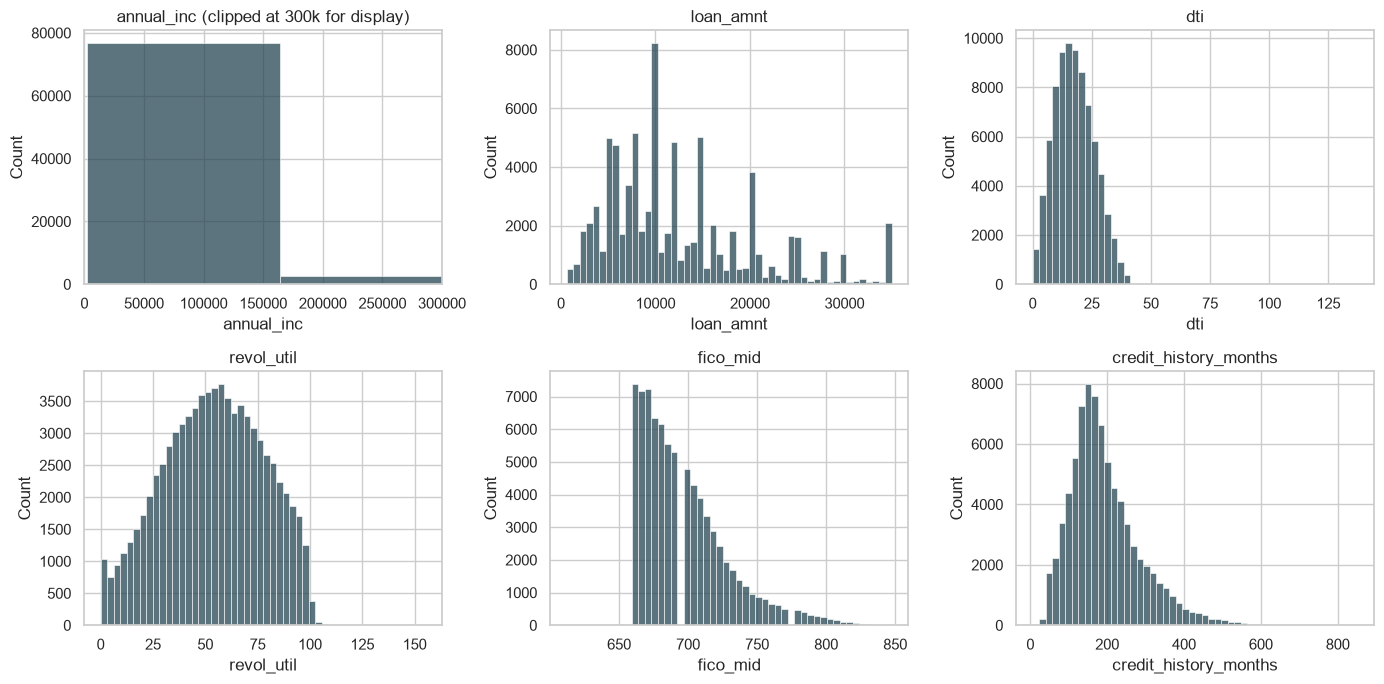

In [8]:
num = ["annual_inc", "loan_amnt", "dti", "revol_util", "fico_mid", "credit_history_months"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
s = df.sample(80_000, seed=42).to_pandas()
for ax, col in zip(axes.ravel(), num, strict=False):
    sns.histplot(s, x=col, bins=50, ax=ax, color="#264653")
    if col == "annual_inc":
        ax.set_xlim(0, 300_000)
        ax.set_title("annual_inc (clipped at 300k for display)")
    else:
        ax.set_title(col)
plt.tight_layout()
plt.savefig(FIG / "distributions.png", dpi=120)
display(df.select(num).describe().to_pandas())

## 8. Categorical columns

Rare levels (under 1% of training rows) are grouped into `other` (**D-018**), so an
unusual value at prediction time cannot surprise the model.

In [9]:
for col in ["purpose", "home_ownership", "verification_status", "initial_list_status"]:
    vc = (
        df.group_by(col)
        .agg(pl.len().alias("loans"), pl.col("target").mean().round(4).alias("default_rate"))
        .sort("loans", descending=True)
    )
    print(f"\n=== {col} ({vc.height} levels) ===")
    display(vc.to_pandas())


=== purpose (14 levels) ===


,purpose,loans,default_rate
0,debt_consolidation,351789,0.1460
1,credit_card,150388,0.1162
2,home_improvement,35828,0.1248
3,other,34092,0.1624
4,major_purchase,13027,0.1243
5,small_business,7551,0.2280
6,medical,6960,0.1711
7,car,6954,0.1149
8,moving,4662,0.1915
9,vacation,4328,0.1562



=== home_ownership (6 levels) ===


,home_ownership,loans,default_rate
0,MORTGAGE,288340,0.1145
1,RENT,269418,0.1640
2,OWN,63044,0.1485
3,OTHER,175,0.2000
4,NONE,43,0.1628
5,ANY,2,0.0000



=== verification_status (3 levels) ===


,verification_status,loans,default_rate
0,Source Verified,217957,0.1421
1,Not Verified,217339,0.1175
2,Verified,185726,0.1621



=== initial_list_status (2 levels) ===


,initial_list_status,loans,default_rate
0,f,346580,0.1460
1,w,274442,0.1311


## 9. Findings that changed the plan

| # | Finding | Consequence |
|---|---|---|
| 1 | 621,022 loans survive the filters; default rate **13.95%** | Imbalance is moderate — no resampling needed (**D-021**) |
| 2 | Default rate by split: train 12.6% → validation 13.7% → test 14.9% | Real prior drift; calibration on 2014 matters (**D-024**) |
| 3 | 2016–18 finished loans show ~20% defaults | Confirms the maturity cutoff (**D-004**) |
| 4 | Charged-off loans repay ~64% of principal | LGD ≈ 0.36, not 0.65 → profit rule updated (**D-032**) |
| 5 | Average loan earns **+$1,029**; fund-all is profitable | The baseline to beat is a positive return, not zero |
| 6 | `mort_acc`, `tot_cur_bal`, `tot_coll_amt` are 100% missing pre-2012 | Dropped (**D-030**) |
| 7 | `application_type` is 99.96% "Individual" | Dropped — no signal (**D-030**) |
| 8 | `int_rate` and `revol_util` are already numeric in this mirror | No percent-string parsing needed (**D-033**) |
| 9 | `dti` uses 999 as a sentinel; 2 loans have `annual_inc = 0` | Both converted to missing in `prepare.py` |
| 10 | Grade A→G default rate rises from ~5% to ~30% | Lending Club's grade is a strong baseline our model must beat (**D-007**) |